# Spotify Data Analysis – Advanced Analysis

## Objective

In this phase, I will compare tracks with different popularity levels to identify whether certain Spotify audio characteristics are more common among highly popular tracks.

The goal is to move beyond individual correlations and analyse patterns across groups of tracks.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv(
    r"F:\Project\Spotify\data\processed\spotify_cleaned.csv"
)

print("Dataset Shape:", df.shape)
df.head()



Dataset Shape: (898694, 16)


,track_id,genres,track_artists,tempo,energy,key,popularity,mode,time_signature,speechiness,danceability,valence,acousticness,liveness,instrumentalness,name
0,07vS8obfeZbr8H4MgQfXR7,"['indie pop', 'la indie', 'pov: indie']",Phoebe Bridgers,97.129,0.123,7.0,0.0,1.0,4.0,0.0407,0.373,0.138,0.9480,0.0816,0.000000,Friday I'm In Love - Recorded at Spotify Studi...
1,1PEqh7awkpuepLBSq8ZwqD,"['lilith', 'new wave pop']",unknown,103.773,0.453,5.0,71.0,1.0,4.0,0.0348,0.744,0.122,0.6270,0.0898,0.421000,I Love You Always Forever
2,7E8pPgBY84oDaXRcqODavR,"['deep groove house', 'house', 'tech house']",unknown,122.030,0.878,9.0,0.0,0.0,4.0,0.0357,0.747,0.897,0.0794,0.3700,0.000531,Love Too Deep - Radio Edit
3,0Atml4huw4Fgyk6YSHiK4M,[],unknown,84.099,0.484,7.0,0.0,1.0,4.0,0.0356,0.604,0.564,0.1000,0.0865,0.000000,No Tiren Las Botellas
4,4WYDmIZrwxBHdBYdvi5oQO,"['chill lounge', 'deep chill']",unknown,156.017,0.447,0.0,7.0,1.0,4.0,0.0613,0.761,0.761,0.0616,0.0822,0.873000,El Momento de Despertar - Blue Sky Mix


## 1. Creating Popularity Groups

### Question

How can I divide the tracks into different popularity levels?

The dataset contains a large number of tracks with different popularity scores. Instead of comparing every individual popularity value, I decided to divide the tracks into four groups.

This will make it easier to compare the audio characteristics of less popular tracks and highly popular tracks.


In [6]:
df['popularity_group'] = pd.qcut(
    df['popularity'],
    q=4,
    labels = [
        'Low',
        'Medium',
        'High'
    ],
    duplicates='drop'
)

popularity_group_count = (
    df['popularity_group']
    .value_counts()
    .sort_index()
)
print(popularity_group_count)

popularity_group
Low       459159
Medium    215623
High      223912
Name: count, dtype: int64


## 2. Audio Features by Popularity Group

### Question

How do the audio features change between different popularity groups?

Here, I am comparing the average audio features of tracks in the Low, Medium-Low, Medium-High and High popularity groups.

This analysis will help me understand whether some audio characteristics change as track popularity increases.


In [ ]:
audio_features = [
    'energy',
    'danceability',
    'valence',
    'acousticness',
    'speechiness',
    'liveness',
    'instrumentalness'
]
popularity_profile = (
    df.groupby(
        'popularity_group',
        observed=True
    )
    [audio_features].mean()
    )
print(popularity_profile)


                    energy  danceability   valence  acousticness  speechiness  \
popularity_group                                                                
Low               0.507571      0.534101  0.428362      0.454573     0.078447   
Medium            0.540418      0.547110  0.424934      0.406753     0.078053   
High              0.588420      0.587645  0.467947      0.339574     0.088130   

                  liveness  instrumentalness  
popularity_group                              
Low               0.186571          0.353429  
Medium            0.187111          0.316249  
High              0.186267          0.176150  


## 3. Comparing Low and High Popularity Tracks

### Question

What are the main differences between low popularity and highly popular tracks?

After comparing all four popularity groups, I wanted to make a more direct comparison between the two extreme groups.

In this section, I am comparing the average audio characteristics of Low popularity tracks with High popularity tracks.


In [11]:
low = df[df['popularity_group'] == 'Low']
high = df[df['popularity_group'] == 'High']

compare = pd.DataFrame({
    'Low Popularity':low[audio_features].mean(),
    'High Popularity':high[audio_features].mean()
})
print(compare)
compare['Difference']=(compare['High Popularity']-compare['Low Popularity'])
compare=compare.sort_values(
    'Difference',
    ascending=False
)
print(compare)

                  Low Popularity  High Popularity
energy                  0.507571         0.588420
danceability            0.534101         0.587645
valence                 0.428362         0.467947
acousticness            0.454573         0.339574
speechiness             0.078447         0.088130
liveness                0.186571         0.186267
instrumentalness        0.353429         0.176150
                  Low Popularity  High Popularity  Difference
energy                  0.507571         0.588420    0.080849
danceability            0.534101         0.587645    0.053545
valence                 0.428362         0.467947    0.039585
speechiness             0.078447         0.088130    0.009683
liveness                0.186571         0.186267   -0.000304
acousticness            0.454573         0.339574   -0.114999
instrumentalness        0.353429         0.176150   -0.177279


### Observation

This comparison shows which audio features have the biggest differences between Low and High popularity tracks.

The difference column makes it easier to identify which features increase or decrease the most when comparing these two groups.


## 4. Characteristics of the Top 10% Popular Tracks

### Question

How are the top 10% most popular tracks different from the overall dataset?

In the previous analysis, I compared tracks using four popularity groups. In this section, I wanted to focus specifically on the most popular tracks in the dataset.

I selected the top 10% of tracks based on popularity and compared their average audio characteristics with the overall dataset.


In [13]:
popularity_threshold = (
    df['popularity'].quantile(0.90)
)
print("Top 10% Popularity Threshold:",popularity_threshold)
top_tracks = df[df['popularity']>=popularity_threshold]
print("Number of Highly Popular Tracks:",len(top_tracks))
overall_profile = (df[audio_features].mean())
top_profile = (top_tracks[audio_features].mean())
profile_comparison = pd.DataFrame({
    'Overall Dataset': overall_profile,
    'Top 10% Popular Tracks': top_profile
})
print(profile_comparison)

Top 10% Popularity Threshold: 50.0
Number of Highly Popular Tracks: 95245
                  Overall Dataset  Top 10% Popular Tracks
energy                   0.535596                0.613097
danceability             0.550563                0.606135
valence                  0.437402                0.494258
acousticness             0.414448                0.309038
speechiness              0.080765                0.091187
liveness                 0.186625                0.186274
instrumentalness         0.300339                0.115054


### Observation

This comparison helps me understand whether the most popular tracks have a different overall audio profile compared with all tracks in the dataset.

I will focus on the features that show the biggest difference between the Top 10% tracks and the overall dataset.


## 5. Genre Performance Analysis

### Question

Which genres perform well based on their popularity?

In the EDA phase, I looked at the most common genres and the genres with high average popularity.

In this analysis, I am looking at genre performance using average popularity, median popularity and the number of tracks.

I included the number of tracks because a genre with only a few tracks may show an unusually high average popularity.


In [14]:
genre_performance = (df.groupby('genres').agg(average_popularity=('popularity','mean'),
        median_popularity=(
            'popularity',
            'median'
        ),
        track_count=(
            'popularity',
            'count'
        )
    )
)
genre_performance = genre_performance[
    genre_performance['track_count'] >= 100
]
top_genre_performance = (
    genre_performance
    .sort_values(
        'average_popularity',
        ascending=False
    )
    .head(15)
)
print(top_genre_performance)

                                                    average_popularity  \
genres                                                                   
['healing hz', 'meditation']                                 61.323308   
['hip hop', 'rap', 'slap house']                             61.064220   
['corrido', 'corridos tumbados', 'musica mexica...           57.500000   
['colombian pop', 'pop reggaeton', 'reggaeton',...           56.254902   
['corrido', 'corridos tumbados', 'sad sierreno'...           55.021552   
['classic oklahoma country']                                 54.520710   
['trap latino', 'urbano latino']                             54.282609   
['arrocha', 'sertanejo', 'sertanejo universitar...           53.847222   
['alternative metal', 'nu metal', 'rap metal', ...           53.575758   
['hip hop', 'rap']                                           53.442857   
['filmi', 'indian instrumental', 'modern bollyw...           53.372449   
['reggaeton', 'reggaeton flow', 'trap 

### Observation

Using average popularity together with median popularity and track count gives a better understanding of genre performance.

This helps me avoid making conclusions based only on a genre that has a very small number of tracks.


## 6. Popularity and Musical Mode

### Question

Is the distribution of Major and Minor tracks different among highly popular tracks?

In this section, I am comparing the Major and Minor mode distribution of the complete dataset with the distribution of the Top 10% most popular tracks.

This will help me check whether one musical mode appears more frequently among highly popular tracks.


           Overall Dataset (%)  Top 10% Popular Tracks (%)
mode_name                                                 
Major                62.800686                   61.530789
Minor                37.199314                   38.469211


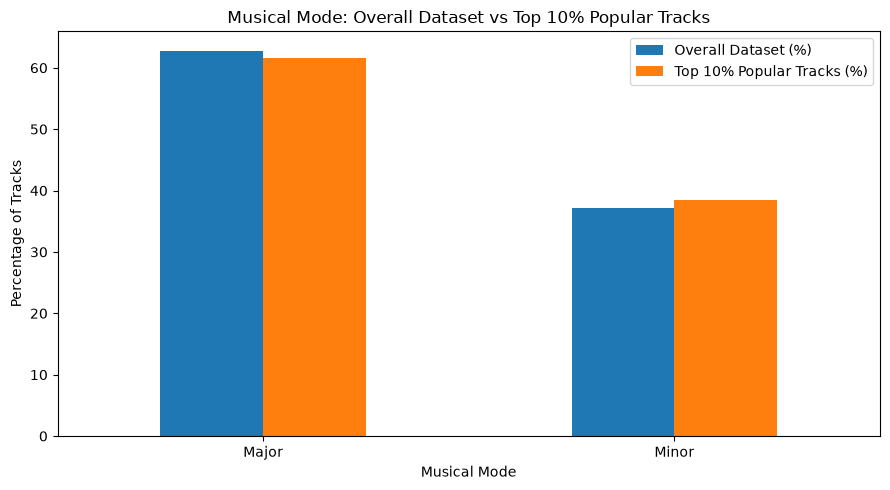

In [18]:
df['mode_name'] = df['mode'].map({
    0: 'Minor',
    1: 'Major'
})
threshold = df['popularity'].quantile(0.90)
top_tracks = df[
    df['popularity'] >= threshold
].copy()
overall_mode = (
    df['mode_name']
    .value_counts(
        normalize=True
    )
    * 100
)
top_mode = (
    top_tracks['mode_name']
    .value_counts(
        normalize=True
    )
    * 100
)
mode_comparison = pd.DataFrame({
    'Overall Dataset (%)': overall_mode,
    'Top 10% Popular Tracks (%)': top_mode
})
print(mode_comparison)
mode_comparison.plot(
    kind='bar',
    figsize=(9, 5)
)
plt.title('Musical Mode: Overall Dataset vs Top 10% Popular Tracks')
plt.xlabel('Musical Mode')
plt.ylabel('Percentage of Tracks')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Observation

This comparison shows whether the proportion of Major and Minor tracks changes when we look only at highly popular tracks.

A difference in the distribution may show an interesting pattern, but it does not mean that musical mode alone determines track popularity.


# 7. Final Key Findings

After completing the advanced analysis, I found some clear differences between low popularity and highly popular tracks.

### 1. Highly Popular Tracks Are More Energetic and Danceable

One of the clearest patterns I found was that highly popular tracks have higher average energy and danceability.

For example, the average energy increased from approximately **0.51 for Low popularity tracks to 0.59 for High popularity tracks**. Danceability also increased from approximately **0.53 to 0.59**.

This suggests that more energetic and danceable tracks appear more frequently among the highly popular tracks in this dataset.

### 2. Instrumentalness Shows the Biggest Difference

The biggest difference between Low and High popularity tracks was found in **instrumentalness**.

Low popularity tracks had an average instrumentalness of approximately **0.35**, while High popularity tracks had an average of approximately **0.18**.

The Top 10% most popular tracks showed an even lower average instrumentalness of approximately **0.12**.

This was one of the strongest patterns I found in the analysis. Highly popular tracks in this dataset tend to be less instrumental compared with less popular tracks.

### 3. Highly Popular Tracks Are Less Acoustic

Another noticeable difference was found in acousticness.

Low popularity tracks had a higher average acousticness of approximately **0.45**, while High popularity tracks had an average of approximately **0.34**.

The Top 10% most popular tracks had an even lower average acousticness of approximately **0.31**.

This suggests that highly popular tracks in this dataset tend to be less acoustic compared with the less popular tracks.

### 4. The Top 10% Popular Tracks Have a Different Audio Profile

The Top 10% most popular tracks were defined as tracks with a popularity score of **50 or higher**. There were **95,245 tracks** in this group.

When I compared these tracks with the complete dataset, I found that the Top 10% tracks had higher average energy, danceability and valence.

They also had lower average acousticness and instrumentalness.

Liveness showed almost no difference between the overall dataset and the Top 10% popular tracks.

This shows that highly popular tracks have a somewhat different audio profile compared with the overall Spotify dataset.

### 5. Genre Performance

The genre analysis showed that some genres performed particularly well when average popularity was considered along with the number of tracks.

Among the genres with at least 100 tracks, combinations related to **healing and meditation** had the highest average popularity in this analysis, followed closely by some **hip hop and rap-related genres**.

This shows that the most common genre is not necessarily the genre with the highest average popularity.

### 6. Major and Minor Mode Distribution

Major mode was more common in both the complete dataset and among the Top 10% most popular tracks.

In the complete dataset, approximately **62.8% of tracks were in Major mode**, while approximately **37.2% were in Minor mode**.

Among the Top 10% most popular tracks, approximately **61.5% were Major** and **38.5% were Minor**.

The difference between these distributions was relatively small. This suggests that musical mode alone does not have a strong relationship with track popularity.

### 7. Overall Conclusion

Overall, the analysis shows that highly popular tracks do have some noticeable audio characteristics.

Highly popular tracks in this dataset tend to be more energetic, more danceable, less acoustic and significantly less instrumental compared with less popular tracks.

However, no single feature can completely explain why a track becomes popular. Track popularity is likely influenced by a combination of musical characteristics along with other factors that are not included in this dataset, such as artist popularity, marketing, playlist exposure and listener preferences.

This advanced analysis provides a deeper understanding of the differences between low popularity and highly popular Spotify tracks and gives a good foundation for the next phase of the project.
